# DBSCAN Clustering Analysis for Credit Card Data

本 Notebook 演示如何使用 DBSCAN 算法对信用卡客户数据进行聚类。涵盖了从参数选择（K-距离图）、模型构建、降维可视化到业务画像分析的全过程。

## 1. 导入库与加载标准化数据

导入 `sklearn`, `pandas`, `numpy`, `matplotlib` 等必要库。读取预处理后的标准化数据文件 `CC_GENERAL_standardized.csv`。DBSCAN 基于欧氏距离，必须确保输入数据已完成标准化处理以避免量纲差异导致的聚类失效。

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

# 设置绘图风格
sns.set(style="whitegrid")

# 加载原始数据
data_path = 'preprocess_data/dataset/CC_GENERAL.csv'
df = pd.read_csv(data_path)

# 加载标准化数据
data_path = 'preprocess_data/dataset/CC_GENERAL_standardized.csv'
df_std = pd.read_csv(data_path)

print("Data shape:", df_std.shape)
df_std.head()

Data shape: (8950, 17)


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,-0.877821,-1.021875,-0.729687,-0.692383,-0.505216,-0.673507,-0.806490,-0.722749,-0.707313,-0.730084,-0.697293,-0.737970,-1.010503,-0.899859,-0.784078,-0.629277,0.0
1,1.178546,-0.202708,-0.838160,-0.692383,-0.746029,2.115343,-1.221758,-0.722749,-0.916995,0.717792,0.473089,-0.891333,0.762757,2.165375,0.968887,0.973961,0.0
2,0.718487,0.616459,0.040957,0.818320,-0.746029,-0.673507,1.269843,2.210909,-0.916995,-0.730084,-0.697293,0.028848,0.910528,-0.569653,0.132544,-0.629277,0.0
3,0.179623,-1.886552,0.866246,2.128108,-0.746029,-0.467401,-1.014125,-0.396788,-0.916995,-0.247460,-0.404697,-0.814651,0.910528,-1.058417,-0.459290,-0.629277,0.0
4,-0.372561,0.616459,-0.819967,-0.661121,-0.746029,-0.673507,-1.014125,-0.396788,-0.916995,-0.730084,-0.697293,-0.814651,-0.951394,-0.525443,-0.586234,-0.629277,0.0


## 2. 确定 Min_Samples 参数

根据启发式规则设定 `min_samples`。由于数据具有 17 个特征维度，根据经验法则 ($min\_samples \ge dim + 1$)，建议将初始值设定在 18 到 34 之间。较大的值有助于在大型数据集中减少噪声干扰。

这里我们初步设定 `min_samples` 为 34 (2 * dim)。

In [26]:
min_samples = 34
print(f"Selected min_samples: {min_samples}")

Selected min_samples: 34


## 3. 使用 K-距离图确定最佳 Eps 参数

计算每个样本点到其第 $k$ 个最近邻（$k=min\_samples$）的距离。绘制 K-distance graph（K-距离图），通过观察曲线急剧下降并趋于平缓的“肘部”位置（Elbow Point），确定最佳 `eps`（邻域半径）的候选值。

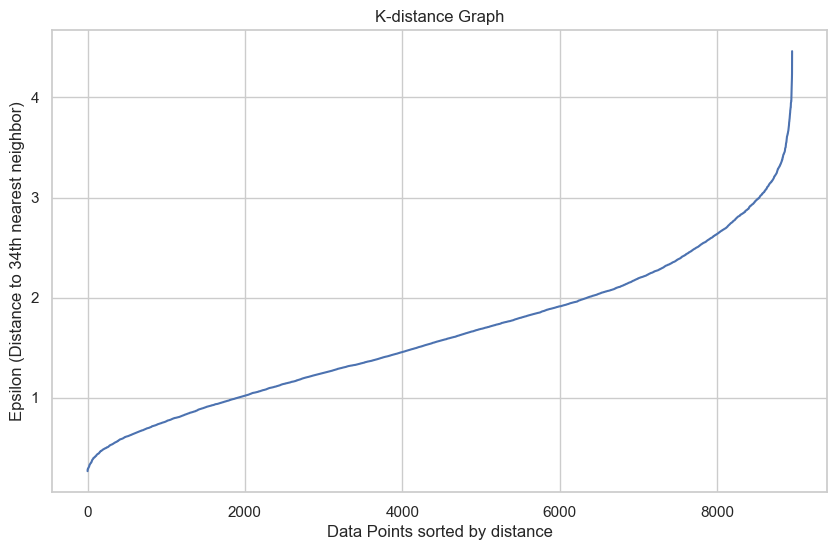

In [27]:
# 计算 K-Nearest Neighbors
neighbors = NearestNeighbors(n_neighbors=min_samples)
neighbors_fit = neighbors.fit(df_std)
distances, indices = neighbors_fit.kneighbors(df_std)

# 对距离进行排序
distances = np.sort(distances[:, min_samples-1], axis=0)

# 绘制 K-distance Graph
plt.figure(figsize=(10, 6))
plt.plot(distances)
plt.title('K-distance Graph')
plt.xlabel('Data Points sorted by distance')
plt.ylabel(f'Epsilon (Distance to {min_samples}th nearest neighbor)')
plt.grid(True)
plt.show()

**观察上图：**
寻找曲线的“肘部”（Elbow Point），即斜率发生显著变化的地方。这个点的 Y 轴值通常作为 `eps` 的最佳候选值。
(在实际运行后，请根据图表调整下面的 eps_candidates 范围)

## 4. 构建 DBSCAN 模型与网格搜索调优

实例化 `sklearn.cluster.DBSCAN` 模型。虽然已通过 K-dist 找到理论 `eps`，但仍需在理论值附近进行小范围的网格搜索。提取模型拟合后的 `.labels_`，注意标签为 -1 的点代表噪声点（异常值）。

我们将尝试不同的 `eps` 和 `min_samples` 组合，并使用轮廓系数（Silhouette Score）来评估效果。

In [28]:
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score

# --- 修改策略：大幅降低 eps，尝试更细粒度的切分 ---
# np.arange(start, stop, step)
eps_values = np.arange(0.5, 2.0, 0.2)  # [0.5, 0.7, 0.9, 1.1, 1.3, 1.5, 1.7, 1.9]
min_samples_values = [15, 20, 25, 30]  # 稍微放宽下限，因为 eps 变小了，圈子里的人会变少

best_score = -1
best_params = {}

print(f"{'Eps':<6} | {'MinPts':<8} | {'Score':<8} | {'Clusters':<8} | {'Noise':<8}")
print("-" * 55)

for eps in eps_values:
    for ms in min_samples_values:
        dbscan = DBSCAN(eps=eps, min_samples=ms)
        labels = dbscan.fit_predict(df_std)
        
        # 统计簇数量 (排除噪声 -1)
        unique_labels = set(labels)
        n_clusters = len(unique_labels) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        
        # 只有当簇数量 > 1 且 < 10 (避免过于破碎) 时才计算分数
        if 1 < n_clusters < 15:
            score = silhouette_score(df_std, labels)
            print(f"{eps:<6.1f} | {ms:<8} | {score:<.4f}   | {n_clusters:<8} | {n_noise:<8} <--- 有效候选")
            
            if score > best_score:
                best_score = score
                best_params = {'eps': eps, 'min_samples': ms}
                best_labels = labels
        else:
            # 即使无效，也打印出来以便调试：
            # 如果 Clusters=1 且 Noise很少 -> Eps 太大
            # 如果 Clusters=0 或 Noise极大 -> Eps 太小
            print(f"{eps:<6.1f} | {ms:<8} | {'-----':<8} | {n_clusters:<8} | {n_noise:<8}")

print("-" * 55)
print("Best Parameters:", best_params)
print("Best Silhouette Score:", best_score)

Eps    | MinPts   | Score    | Clusters | Noise   
-------------------------------------------------------
0.5    | 15       | -0.2552   | 8        | 7926     <--- 有效候选
0.5    | 20       | -0.2554   | 6        | 8079     <--- 有效候选
0.5    | 25       | -0.2761   | 6        | 8243     <--- 有效候选
0.5    | 30       | -0.2531   | 4        | 8375     <--- 有效候选
0.7    | 15       | -0.2603   | 8        | 6861     <--- 有效候选
0.7    | 20       | -0.1791   | 8        | 7103     <--- 有效候选
0.7    | 25       | -0.1458   | 6        | 7298     <--- 有效候选
0.7    | 30       | -0.1751   | 6        | 7421     <--- 有效候选
0.9    | 15       | -0.0179   | 3        | 5621     <--- 有效候选
0.9    | 20       | -0.1536   | 6        | 5899     <--- 有效候选
0.9    | 25       | -0.0535   | 3        | 6132     <--- 有效候选
0.9    | 30       | -0.0827   | 3        | 6328     <--- 有效候选
1.1    | 15       | -0.0535   | 6        | 4378     <--- 有效候选
1.1    | 20       | 0.0005   | 4        | 4671     <--- 有效候选
1.1    | 25       | 0.0215

## 5. 使用 PCA 进行降维可视化

由于数据为 17 维，需使用 PCA（主成分分析）将其压缩至 2 维以便绘图。绘制散点图，将聚类标签映射为颜色，并特意将噪声点（Label -1）标记为灰色或黑色，以观察异常值的分布情况。

--- Training Final Model with eps=1.3, min_samples=30 ---

Cluster Distribution (Label -1 is Noise):
-1    3994
 0    4784
 1     138
 2      34
Name: count, dtype: int64


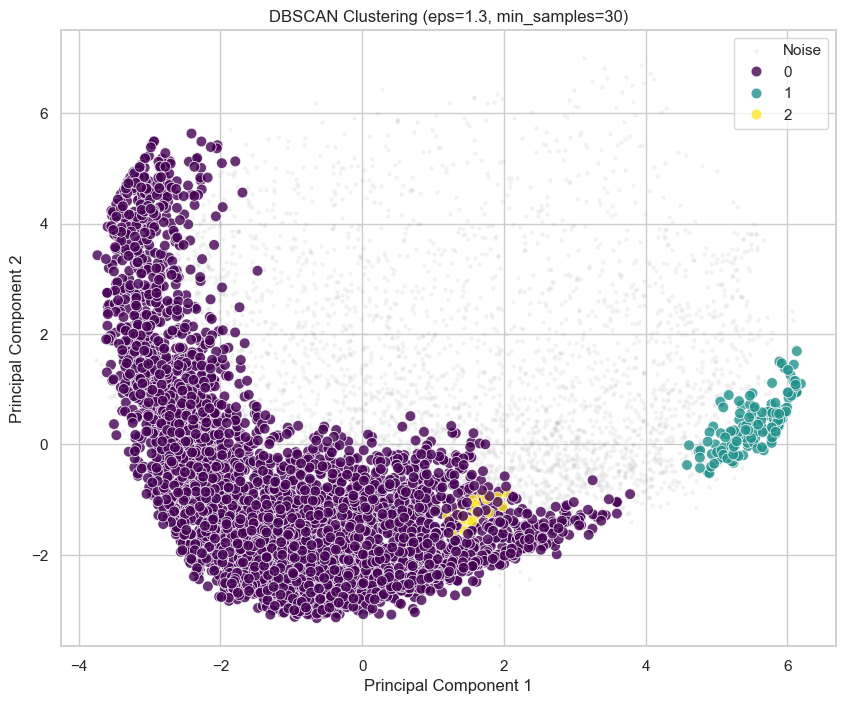

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA

# ==========================================
# 1. 设置最终参数 (调整为 3 类)
# ==========================================
# 根据网格搜索结果，尝试 eps=1.3, min_samples=30 以获得 3 个簇
final_eps = 1.3
final_min_samples = 30

print(f"--- Training Final Model with eps={final_eps}, min_samples={final_min_samples} ---")

# 2. 训练模型
dbscan = DBSCAN(eps=final_eps, min_samples=final_min_samples)
labels = dbscan.fit_predict(df_std) # 确保使用 standardized 的数据

# 3. 检查簇的分布情况
distribution = pd.Series(labels).value_counts().sort_index()
print("\nCluster Distribution (Label -1 is Noise):")
print(distribution)

# 4. PCA 降维可视化
pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_std)

# 创建绘图 DataFrame
df_vis = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
df_vis['Cluster'] = labels

# 绘图
plt.figure(figsize=(10, 8))
# 单独画噪声点
sns.scatterplot(
    x='PC1', y='PC2', 
    data=df_vis[df_vis['Cluster'] == -1], 
    color='gray', label='Noise', alpha=0.1, s=10
)
# 画核心簇
sns.scatterplot(
    x='PC1', y='PC2', 
    data=df_vis[df_vis['Cluster'] != -1], 
    hue='Cluster', palette='viridis', s=60, alpha=0.8
)
plt.title(f'DBSCAN Clustering (eps={final_eps}, min_samples={final_min_samples})')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()

In [30]:
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# --- 聚类效果评估指标 (基于标准化数据) ---
print("--- 聚类效果评估指标 (基于标准化数据) ---")

# 过滤掉噪声点进行评估 (DBSCAN 评估通常需要排除噪声)
mask = labels != -1
if len(set(labels[mask])) > 1:
    s_score = silhouette_score(df_std[mask], labels[mask])
    ch_score = calinski_harabasz_score(df_std[mask], labels[mask])
    db_score = davies_bouldin_score(df_std[mask], labels[mask])
    
    print(f"检测到噪声点 (Label=-1), 共 {list(labels).count(-1)} 个。正在剔除噪声点以计算聚类指标...")
    print(f"Silhouette Score (轮廓系数): {s_score:.4f} (越接近 1 越好)")
    print(f"Calinski-Harabasz Index: {ch_score:.4f} (越大越好)")
    print(f"Davies-Bouldin Index: {db_score:.4f} (越小越好)")
else:
    print("无法计算指标：聚类数量不足（排除噪声后少于2个簇）。")

--- 聚类效果评估指标 (基于标准化数据) ---
检测到噪声点 (Label=-1), 共 3994 个。正在剔除噪声点以计算聚类指标...
Silhouette Score (轮廓系数): 0.2187 (越接近 1 越好)
Calinski-Harabasz Index: 378.3138 (越大越好)
Davies-Bouldin Index: 0.8117 (越小越好)


In [31]:
# ==========================================
# 重新运行最佳模型 (eps=1.3, min_samples=30)
# ==========================================
dbscan = DBSCAN(eps=1.3, min_samples=30)
labels = dbscan.fit_predict(df_std) # 使用标准化数据训练

# 将标签拼接到【原始数据】(df) 上
df['Cluster_Labels'] = labels

# 排除噪声点 (-1)，计算各簇均值
profile_cols = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'PAYMENTS', 'CREDIT_LIMIT', 'PRC_FULL_PAYMENT', 'TENURE']
cluster_profile = df[df['Cluster_Labels'] != -1].groupby('Cluster_Labels')[profile_cols].mean()

print("--- 各簇特征均值 (Mean Values) ---")
print(cluster_profile.round(2))

--- 各簇特征均值 (Mean Values) ---
                BALANCE  PURCHASES  CASH_ADVANCE  PAYMENTS  CREDIT_LIMIT  \
Cluster_Labels                                                             
0               1145.87     249.75        674.99    737.90       3154.05   
1                555.96    5714.47         11.90   5361.43       6839.49   
2                 55.87     600.23          0.00    638.44       5876.47   

                PRC_FULL_PAYMENT  TENURE  
Cluster_Labels                            
0                           0.14   11.47  
1                           0.76   11.98  
2                           0.72   12.00  


D:\TEMP\USER_TEMP\ipykernel_27824\270599888.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster_Labels', y=f'log_{col}', data=plot_df, ax=axes[i], palette='Set2')
D:\TEMP\USER_TEMP\ipykernel_27824\270599888.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster_Labels', y=f'log_{col}', data=plot_df, ax=axes[i], palette='Set2')
D:\TEMP\USER_TEMP\ipykernel_27824\270599888.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Cluster_Labels', y=f'log_{col}', data=plot_df, ax=axes[i], palette='Set2')
D:\TEMP\USER_TEMP\ipyk

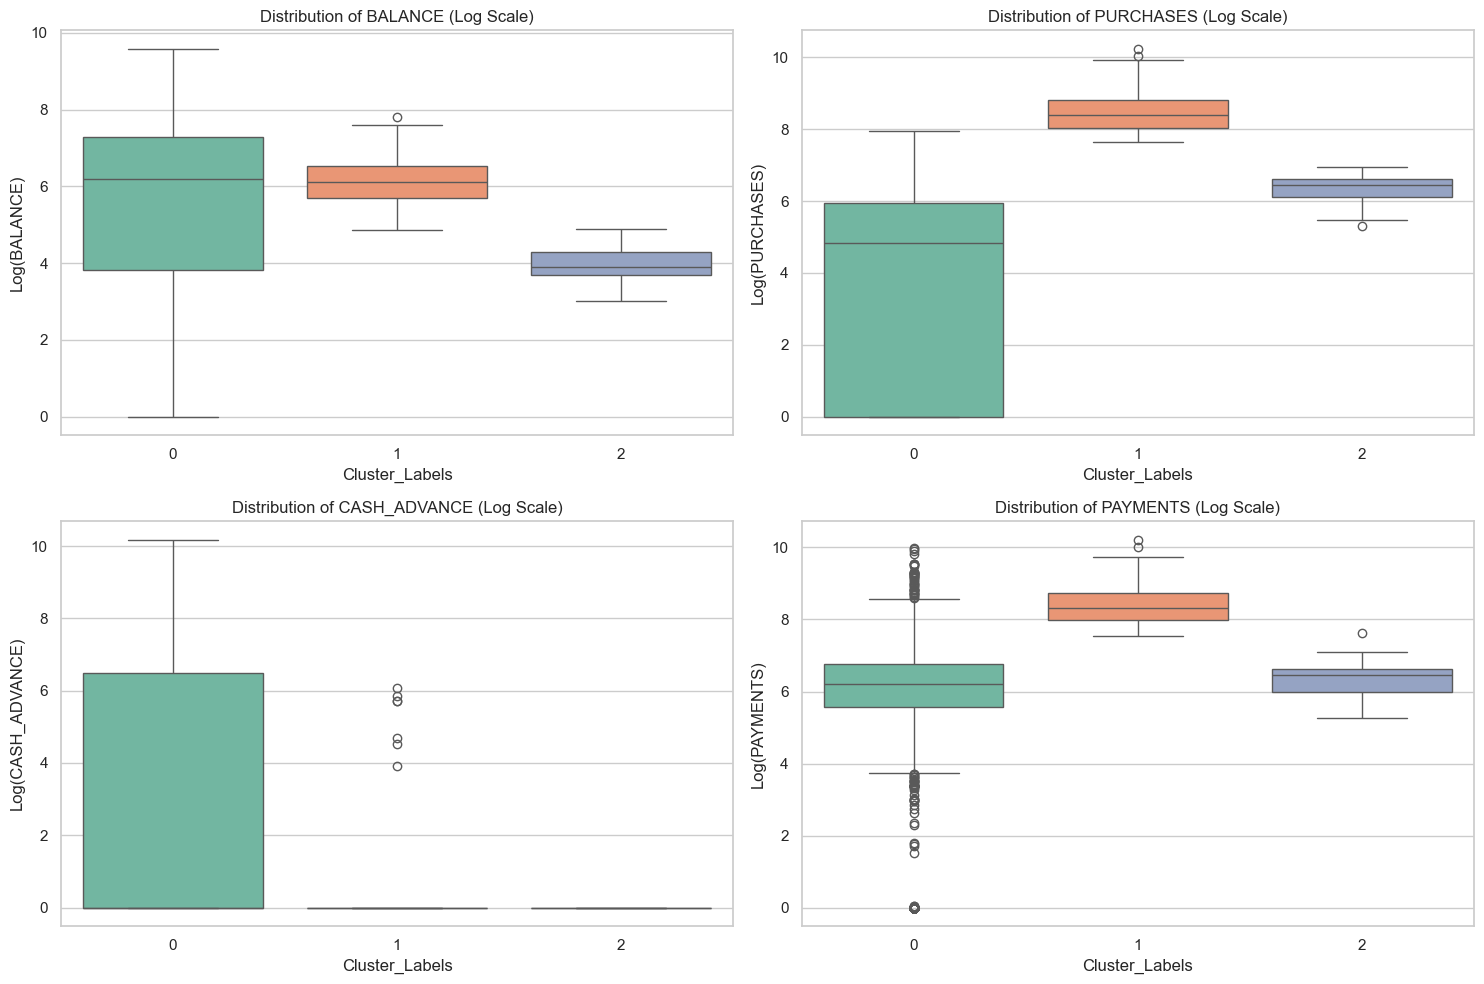

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 准备绘图数据 (只取核心簇，不看噪声)
plot_df = df[df['Cluster_Labels'] != -1].copy()

# 为了可视化方便，对金额类特征做 log1p 处理 (平滑极端值)
# 这样画出来的箱线图不会被压缩成一条线
features_to_plot = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'PAYMENTS']
for col in features_to_plot:
    plot_df[f'log_{col}'] = np.log1p(plot_df[col])

# 绘制 2x2 的子图
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(features_to_plot):
    sns.boxplot(x='Cluster_Labels', y=f'log_{col}', data=plot_df, ax=axes[i], palette='Set2')
    axes[i].set_title(f'Distribution of {col} (Log Scale)')
    axes[i].set_ylabel(f'Log({col})')

plt.tight_layout()
plt.show()

In [33]:
import pandas as pd
from sklearn.cluster import DBSCAN

# 1. 确保使用最终选定的参数重新训练模型
dbscan = DBSCAN(eps=1.3, min_samples=30)
labels = dbscan.fit_predict(df_std)

# 2. 将数字标签添加到原始 DataFrame
df_result = df.copy()
df_result['Cluster_Label'] = labels

# 3. 定义业务含义映射字典 (调整为 3 类)
cluster_mapping = {
    -1: 'Noise (异常/离群点)',
    0: 'Standard User (普通活跃用户)',
    1: 'Prime Transactor (优质全额还款用户)',
    2: 'VIP Spender (高价值/高透支用户)'
}

# 4. 映射生成新的文本列
df_result['Cluster_Description'] = df_result['Cluster_Label'].map(cluster_mapping)

# 5. 查看结果预览
print("--- 数据集前5行 (已添加标签) ---")
print(df_result[['CUST_ID', 'BALANCE', 'PURCHASES', 'Cluster_Label', 'Cluster_Description']].head())

# 6. 保存为 CSV 文件
df_result.to_csv('CC_GENERAL_Clustered_DBSCAN_3Clusters.csv', index=False)
print(f"\n成功保存文件: CC_GENERAL_Clustered_DBSCAN_3Clusters.csv")

# 7. 再次验证各类别数量
print("\n--- 最终各类别统计 ---")
print(df_result['Cluster_Description'].value_counts())

--- 数据集前5行 (已添加标签) ---
  CUST_ID      BALANCE  PURCHASES  Cluster_Label     Cluster_Description
0  C10001    40.900749      95.40              0  Standard User (普通活跃用户)
1  C10002  3202.467416       0.00             -1          Noise (异常/离群点)
2  C10003  2495.148862     773.17             -1          Noise (异常/离群点)
3  C10004  1666.670542    1499.00             -1          Noise (异常/离群点)
4  C10005   817.714335      16.00              0  Standard User (普通活跃用户)

成功保存文件: CC_GENERAL_Clustered_DBSCAN_3Clusters.csv

--- 最终各类别统计 ---
Cluster_Description
Standard User (普通活跃用户)         4784
Noise (异常/离群点)                 3994
Prime Transactor (优质全额还款用户)     138
VIP Spender (高价值/高透支用户)          34
Name: count, dtype: int64
